# Import packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from tqdm import tqdm

from models import model_Millennial

In [2]:
soc_pool_color_dict = {
    'SOC': 'black',
    'POC': '#4DAF4A',
    'MAOC': '#A65628',
    'MIC': '#E41A1C',
    'AGC': '#984EA3',
    'LMWC': '#377EB8',
}

# Model test

100%|██████████| 36501/36501 [00:00<00:00, 144597.98it/s]


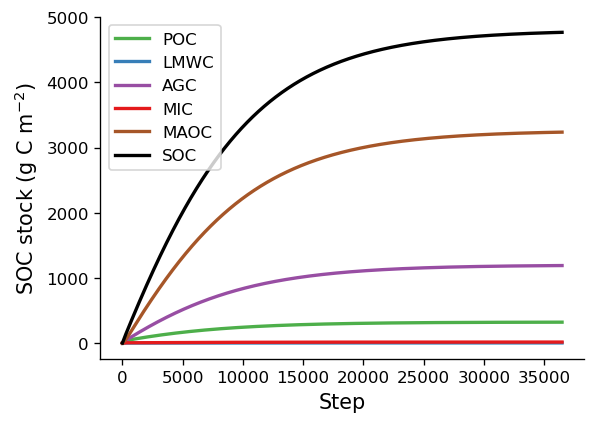

SOC = 4767.1
POC = 321.4
LMWC = 3.3
AGC = 1189.8
MIC = 16.3
MAOC = 3236.2

Proportion of each C pool:
POC = 6.7%
LMWC = 0.1%
AGC = 25.0%
MIC = 0.3%
MAOC = 67.9%


In [3]:
time_list = np.arange(0, 365*100+1, 1)

f_POC = 0.15
f_MAOC = 0.70
f_AGC = 0.10
f_MIC = 0.04
f_LMWC = 0.01
SOC_init = 1
POC_init = SOC_init * f_POC
MAOC_init = SOC_init * f_MAOC
AGC_init = SOC_init * f_AGC
MIC_init = SOC_init * f_MIC
LMWC_init = SOC_init * f_LMWC

POC_list = []
LMWC_list = []
AGC_list = []
MIC_list = []
MAOC_list = []
SOC_list = []
for t in tqdm(time_list):
    if t <= 0:
        POC = POC_init
        LMWC = LMWC_init
        AGC = AGC_init
        MIC = MIC_init
        MAOC = MAOC_init
    else:
        POC, LMWC, AGC, MIC, MAOC = model_Millennial.model_forward(
            POC=POC, LMWC=LMWC, AGC=AGC, MIC=MIC, MAOC=MAOC,
            param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
            T_soil=10,
            SM=0.15,
            C_input=0.5,
            depth=0.2, pH=7.0, BD=1000, claysilt=80
        )
    SOC = POC + LMWC + AGC + MIC + MAOC
    POC_list.append(POC)
    LMWC_list.append(LMWC)
    AGC_list.append(AGC)
    MIC_list.append(MIC)
    MAOC_list.append(MAOC)
    SOC_list.append(SOC)


plt_datalen = len(time_list)
line_width = 2.0
plt.figure(figsize=(5.2, 3.7), dpi=120)
plt.plot(time_list[:plt_datalen], POC_list[:plt_datalen], label='POC', linewidth=line_width, c=soc_pool_color_dict['POC'])
plt.plot(time_list[:plt_datalen], LMWC_list[:plt_datalen], label='LMWC', linewidth=line_width, c=soc_pool_color_dict['LMWC'])
plt.plot(time_list[:plt_datalen], AGC_list[:plt_datalen], label='AGC', linewidth=line_width, c=soc_pool_color_dict['AGC'])
plt.plot(time_list[:plt_datalen], MIC_list[:plt_datalen], label='MIC', linewidth=line_width, c=soc_pool_color_dict['MIC'])
plt.plot(time_list[:plt_datalen], MAOC_list[:plt_datalen], label='MAOC', linewidth=line_width, c=soc_pool_color_dict['MAOC'])
plt.plot(time_list[:plt_datalen], SOC_list[:plt_datalen], label='SOC', linewidth=line_width, c=soc_pool_color_dict['SOC'])
plt.legend()
plt.xlabel('Step', fontsize=12.5)
plt.ylabel('SOC stock (g C m$^{-2}$)', fontsize=12.5)
sns.despine()
# plt.savefig('./figures/Millennial_model_test__spin_up.jpg', bbox_inches='tight', dpi=600)
plt.show()

print('SOC = {:.1f}\nPOC = {:.1f}\nLMWC = {:.1f}\nAGC = {:.1f}\nMIC = {:.1f}\nMAOC = {:.1f}'.format(
    SOC_list[-1], POC_list[-1], LMWC_list[-1], AGC_list[-1], MIC_list[-1], MAOC_list[-1]
))
print()
print('Proportion of each C pool:\nPOC = {:.1f}%\nLMWC = {:.1f}%\nAGC = {:.1f}%\nMIC = {:.1f}%\nMAOC = {:.1f}%'.format(
    POC_list[-1]/SOC_list[-1]*100, LMWC_list[-1]/SOC_list[-1]*100, AGC_list[-1]/SOC_list[-1]*100, MIC_list[-1]/SOC_list[-1]*100, MAOC_list[-1]/SOC_list[-1]*100
))

100%|██████████| 9/9 [00:08<00:00,  1.09it/s]


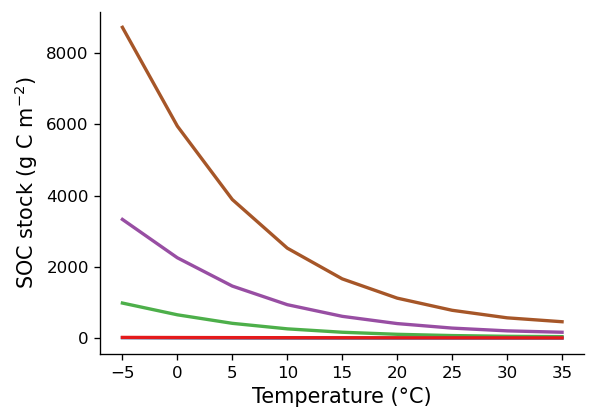

In [4]:
T_soil_list = np.arange(-5, 35+1, 5)

time_list = np.arange(0, 100000+1, 1)

POC_list = []
LMWC_list = []
AGC_list = []
MIC_list = []
MAOC_list = []
SOC_list = []

for T_soil in tqdm(T_soil_list):
    POC_init = 0.1
    LMWC_init = 0.1
    AGC_init = 0.1
    MIC_init = 0.1
    MAOC_init = 0.1
    for t in time_list:
        if t <= 0:
            POC = POC_init
            LMWC = LMWC_init
            AGC = AGC_init
            MIC = MIC_init
            MAOC = MAOC_init
        POC, LMWC, AGC, MIC, MAOC = model_Millennial.model_forward(
            POC=POC, LMWC=LMWC, AGC=AGC, MIC=MIC, MAOC=MAOC,
            param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
            T_soil=T_soil,
            SM=0.15,
            C_input=0.3,
            depth=0.2,
            pH=7.0,
            BD=1000,
            claysilt=80
        )
        SOC = POC + LMWC + AGC + MIC + MAOC
    POC_list.append(POC)
    LMWC_list.append(LMWC)
    AGC_list.append(AGC)
    MIC_list.append(MIC)
    MAOC_list.append(MAOC)
    SOC_list.append(SOC)


line_width = 2.0
plt.figure(figsize=(5.2, 3.7), dpi=120)
plt.plot(T_soil_list, POC_list, label='POC', linewidth=line_width, c=soc_pool_color_dict['POC'])
plt.plot(T_soil_list, LMWC_list, label='LMWC', linewidth=line_width, c=soc_pool_color_dict['LMWC'])
plt.plot(T_soil_list, AGC_list, label='AGC', linewidth=line_width, c=soc_pool_color_dict['AGC'])
plt.plot(T_soil_list, MIC_list, label='MIC', linewidth=line_width, c=soc_pool_color_dict['MIC'])
plt.plot(T_soil_list, MAOC_list, label='MAOC', linewidth=line_width, c=soc_pool_color_dict['MAOC'])
# plt.plot(T_soil_list, SOC_list, label='SOC', linewidth=line_width, c=soc_pool_color_dict['SOC'])
# plt.legend()
plt.xlabel('Temperature (°C)', fontsize=12.5)
plt.ylabel('SOC stock (g C m$^{-2}$)', fontsize=12.5)
sns.despine()

# plt.savefig('./figures/Millennial_model_test__responese_to_temp.jpg', bbox_inches='tight', dpi=600)
plt.show()

100%|██████████| 5/5 [00:03<00:00,  1.48it/s]


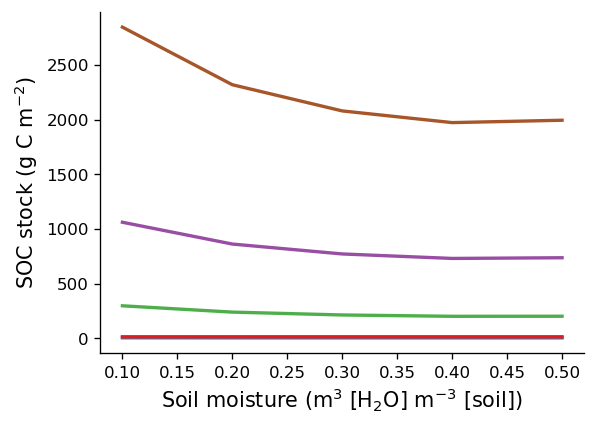

In [5]:
# T_soil_list = np.arange(-10, 40, 5)
sm_list = np.arange(0.1, 0.5+0.1, 0.1)

time_list = np.arange(0, 100000+1, 1)

POC_list = []
LMWC_list = []
AGC_list = []
MIC_list = []
MAOC_list = []
SOC_list = []

for sm in tqdm(sm_list):
    POC_init = 0.1
    LMWC_init = 0.1
    AGC_init = 0.1
    MIC_init = 0.1
    MAOC_init = 0.1
    for t in time_list:
        if t <= 0:
            POC = POC_init
            LMWC = LMWC_init
            AGC = AGC_init
            MIC = MIC_init
            MAOC = MAOC_init
        POC, LMWC, AGC, MIC, MAOC = model_Millennial.model_forward(
            POC=POC, LMWC=LMWC, AGC=AGC, MIC=MIC, MAOC=MAOC,
            param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
            T_soil=10,
            SM=sm,
            C_input=0.3,
            depth=0.2,
            pH=7.0,
            BD=1000,
            claysilt=80
        )
        SOC = POC + LMWC + AGC + MIC + MAOC
    POC_list.append(POC)
    LMWC_list.append(LMWC)
    AGC_list.append(AGC)
    MIC_list.append(MIC)
    MAOC_list.append(MAOC)
    SOC_list.append(SOC)


line_width = 2.0
plt.figure(figsize=(5.2, 3.7), dpi=120)
plt.plot(sm_list, POC_list, label='POC', linewidth=line_width, c=soc_pool_color_dict['POC'])
plt.plot(sm_list, LMWC_list, label='LMWC', linewidth=line_width, c=soc_pool_color_dict['LMWC'])
plt.plot(sm_list, AGC_list, label='AGC', linewidth=line_width, c=soc_pool_color_dict['AGC'])
plt.plot(sm_list, MIC_list, label='MIC', linewidth=line_width, c=soc_pool_color_dict['MIC'])
plt.plot(sm_list, MAOC_list, label='MAOC', linewidth=line_width, c=soc_pool_color_dict['MAOC'])
# plt.plot(sm_list, SOC_list, label='SOC', linewidth=line_width, c=soc_pool_color_dict['SOC'])
# plt.legend()
plt.xlabel('Soil moisture (m$^{3}$ [H$_2$O] m$^{-3}$ [soil])', fontsize=12.5)
plt.ylabel('SOC stock (g C m$^{-2}$)', fontsize=12.5)
sns.despine()

# plt.savefig('./figures/Millennial_model_test__responese_to_sm.jpg', bbox_inches='tight', dpi=600)
plt.show()

100%|██████████| 11/11 [00:07<00:00,  1.54it/s]


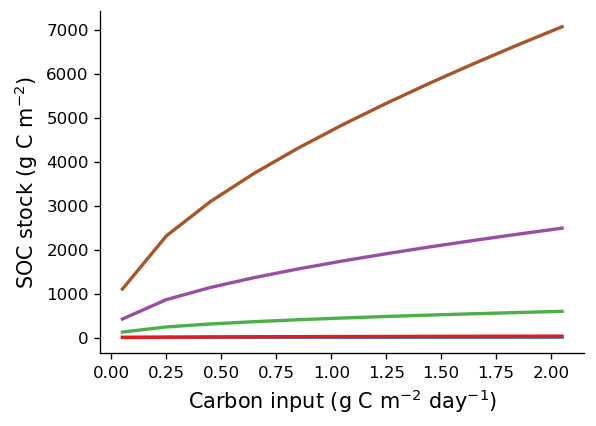

In [6]:
# T_soil_list = np.arange(-10, 40, 5)
c_input_list = np.arange(0.05, 2.0+0.1, 0.2)

time_list = np.arange(0, 100000+1, 1)

POC_list = []
LMWC_list = []
AGC_list = []
MIC_list = []
MAOC_list = []
SOC_list = []

for c_input in tqdm(c_input_list):
    POC_init = 0.1
    LMWC_init = 0.1
    AGC_init = 0.1
    MIC_init = 0.1
    MAOC_init = 0.1
    for t in time_list:
        if t <= 0:
            POC = POC_init
            LMWC = LMWC_init
            AGC = AGC_init
            MIC = MIC_init
            MAOC = MAOC_init
        POC, LMWC, AGC, MIC, MAOC = model_Millennial.model_forward(
            POC=POC, LMWC=LMWC, AGC=AGC, MIC=MIC, MAOC=MAOC,
            param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
            T_soil=10,
            SM=0.15,
            C_input=c_input,
            depth=0.2,
            pH=7.0,
            BD=1000,
            claysilt=80
        )
        SOC = POC + LMWC + AGC + MIC + MAOC
    POC_list.append(POC)
    LMWC_list.append(LMWC)
    AGC_list.append(AGC)
    MIC_list.append(MIC)
    MAOC_list.append(MAOC)
    SOC_list.append(SOC)


line_width = 2.0
plt.figure(figsize=(5.2, 3.7), dpi=120)
plt.plot(c_input_list, POC_list, label='POC', linewidth=line_width, c=soc_pool_color_dict['POC'])
plt.plot(c_input_list, LMWC_list, label='LMWC', linewidth=line_width, c=soc_pool_color_dict['LMWC'])
plt.plot(c_input_list, AGC_list, label='AGC', linewidth=line_width, c=soc_pool_color_dict['AGC'])
plt.plot(c_input_list, MIC_list, label='MIC', linewidth=line_width, c=soc_pool_color_dict['MIC'])
plt.plot(c_input_list, MAOC_list, label='MAOC', linewidth=line_width, c=soc_pool_color_dict['MAOC'])
# plt.plot(c_input_list, SOC_list, label='SOC', linewidth=line_width, c=soc_pool_color_dict['SOC'])
# plt.legend()
plt.xlabel('Carbon input (g C m$^{-2}$ day$^{-1}$)', fontsize=12.5)
plt.ylabel('SOC stock (g C m$^{-2}$)', fontsize=12.5)
sns.despine()

# plt.savefig('./figures/Millennial_model_test__responese_to_cinput.jpg', bbox_inches='tight', dpi=600)
plt.show()

100%|██████████| 9/9 [00:05<00:00,  1.52it/s]


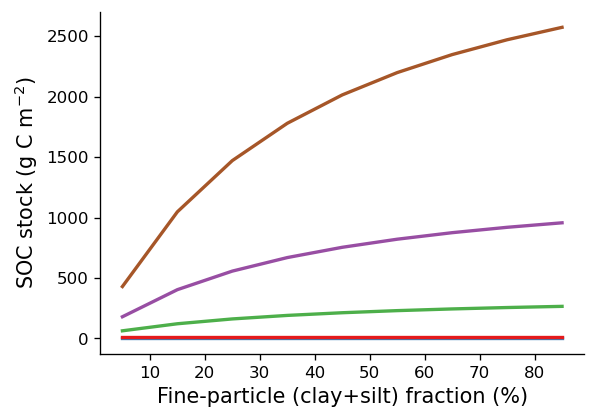

In [7]:
# T_soil_list = np.arange(-10, 40, 5)
claysilt_list = np.arange(5, 90+0.1, 10)

time_list = np.arange(0, 100000+1, 1)

POC_list = []
LMWC_list = []
AGC_list = []
MIC_list = []
MAOC_list = []
SOC_list = []

for claysilt in tqdm(claysilt_list):
    POC_init = 0.1
    LMWC_init = 0.1
    AGC_init = 0.1
    MIC_init = 0.1
    MAOC_init = 0.1
    for t in time_list:
        if t <= 0:
            POC = POC_init
            LMWC = LMWC_init
            AGC = AGC_init
            MIC = MIC_init
            MAOC = MAOC_init
        POC, LMWC, AGC, MIC, MAOC = model_Millennial.model_forward(
            POC=POC, LMWC=LMWC, AGC=AGC, MIC=MIC, MAOC=MAOC,
            param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
            T_soil=10,
            SM=0.15,
            C_input=0.3,
            depth=0.2,
            pH=7.0,
            BD=1000,
            claysilt=claysilt
        )
        SOC = POC + LMWC + AGC + MIC + MAOC
    POC_list.append(POC)
    LMWC_list.append(LMWC)
    AGC_list.append(AGC)
    MIC_list.append(MIC)
    MAOC_list.append(MAOC)
    SOC_list.append(SOC)


line_width = 2.0
plt.figure(figsize=(5.2, 3.7), dpi=120)
plt.plot(claysilt_list, POC_list, label='POC', linewidth=line_width, c=soc_pool_color_dict['POC'])
plt.plot(claysilt_list, LMWC_list, label='LMWC', linewidth=line_width, c=soc_pool_color_dict['LMWC'])
plt.plot(claysilt_list, AGC_list, label='AGC', linewidth=line_width, c=soc_pool_color_dict['AGC'])
plt.plot(claysilt_list, MIC_list, label='MIC', linewidth=line_width, c=soc_pool_color_dict['MIC'])
plt.plot(claysilt_list, MAOC_list, label='MAOC', linewidth=line_width, c=soc_pool_color_dict['MAOC'])
# plt.plot(claysilt_list, SOC_list, label='SOC', linewidth=line_width, c=soc_pool_color_dict['SOC'])
# plt.legend()
plt.xlabel('Fine-particle (clay+silt) fraction (%)', fontsize=12.5)
plt.ylabel('SOC stock (g C m$^{-2}$)', fontsize=12.5)
sns.despine()

# plt.savefig('./figures/Millennial_model_test__responese_to_claysilt.jpg', bbox_inches='tight', dpi=600)
plt.show()

100%|██████████| 6/6 [00:03<00:00,  1.51it/s]


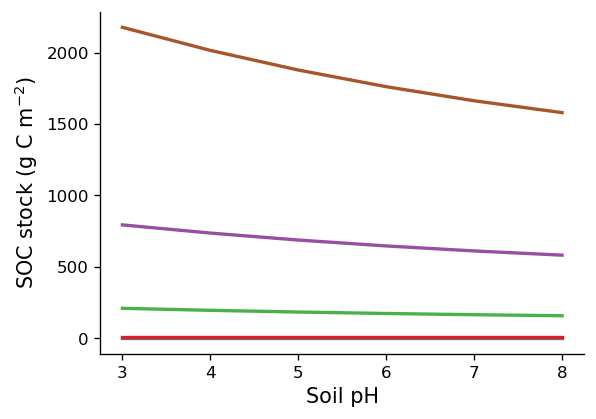

In [8]:
# T_soil_list = np.arange(-10, 40, 5)
pH_soil_list = np.arange(3, 8+0.1, 1)

time_list = np.arange(0, 100000+1, 1)

POC_list = []
LMWC_list = []
AGC_list = []
MIC_list = []
MAOC_list = []
SOC_list = []

for pH_soil in tqdm(pH_soil_list):
    POC_init = 0.1
    LMWC_init = 0.1
    AGC_init = 0.1
    MIC_init = 0.1
    MAOC_init = 0.1
    for t in time_list:
        if t <= 0:
            POC = POC_init
            LMWC = LMWC_init
            AGC = AGC_init
            MIC = MIC_init
            MAOC = MAOC_init
        POC, LMWC, AGC, MIC, MAOC = model_Millennial.model_forward(
            POC=POC, LMWC=LMWC, AGC=AGC, MIC=MIC, MAOC=MAOC,
            param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
            T_soil=15,
            SM=0.15,
            C_input=0.3,
            depth=0.2,
            pH=pH_soil,
            BD=1000,
            claysilt=80
        )
        SOC = POC + LMWC + AGC + MIC + MAOC
    POC_list.append(POC)
    LMWC_list.append(LMWC)
    AGC_list.append(AGC)
    MIC_list.append(MIC)
    MAOC_list.append(MAOC)
    SOC_list.append(SOC)


line_width = 2.0
plt.figure(figsize=(5.2, 3.7), dpi=120)
plt.plot(pH_soil_list, POC_list, label='POC', linewidth=line_width, c=soc_pool_color_dict['POC'])
plt.plot(pH_soil_list, LMWC_list, label='LMWC', linewidth=line_width, c=soc_pool_color_dict['LMWC'])
plt.plot(pH_soil_list, AGC_list, label='AGC', linewidth=line_width, c=soc_pool_color_dict['AGC'])
plt.plot(pH_soil_list, MIC_list, label='MIC', linewidth=line_width, c=soc_pool_color_dict['MIC'])
plt.plot(pH_soil_list, MAOC_list, label='MAOC', linewidth=line_width, c=soc_pool_color_dict['MAOC'])
# plt.plot(pH_soil_list, SOC_list, label='SOC', linewidth=line_width, c=soc_pool_color_dict['SOC'])
# plt.legend()
plt.xlabel('Soil pH', fontsize=12.5)
plt.ylabel('SOC stock (g C m$^{-2}$)', fontsize=12.5)
sns.despine()

# plt.savefig('./figures/Millennial_model_test__responese_to_ph.jpg', bbox_inches='tight', dpi=600)
plt.show()

100%|██████████| 9/9 [00:05<00:00,  1.51it/s]


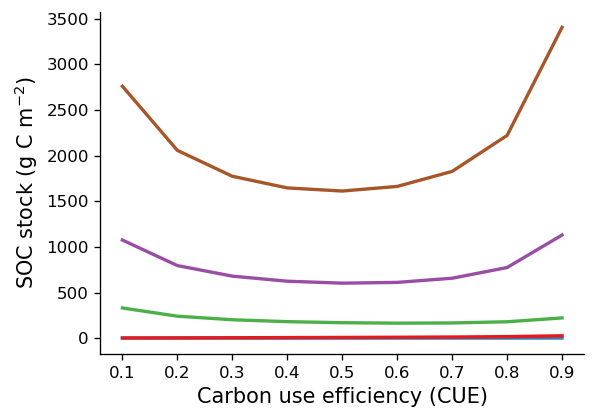

In [9]:
# T_soil_list = np.arange(-10, 40, 5)
cue_ref_list = np.arange(0.1, 1.0, 0.1)

time_list = np.arange(0, 100000+1, 1)

POC_list = []
LMWC_list = []
AGC_list = []
MIC_list = []
MAOC_list = []
SOC_list = []

for cue_ref in tqdm(cue_ref_list):
    POC_init = 0.1
    LMWC_init = 0.1
    AGC_init = 0.1
    MIC_init = 0.1
    MAOC_init = 0.1
    model_Millennial.param_dict['cue_ref'] = cue_ref
    for t in time_list:
        if t <= 0:
            POC = POC_init
            LMWC = LMWC_init
            AGC = AGC_init
            MIC = MIC_init
            MAOC = MAOC_init
        POC, LMWC, AGC, MIC, MAOC = model_Millennial.model_forward(
            POC=POC, LMWC=LMWC, AGC=AGC, MIC=MIC, MAOC=MAOC,
            param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
            T_soil=15,
            SM=0.15,
            C_input=0.3,
            depth=0.2,
            pH=7.0,
            BD=1000,
            claysilt=80
        )
        SOC = POC + LMWC + AGC + MIC + MAOC
    POC_list.append(POC)
    LMWC_list.append(LMWC)
    AGC_list.append(AGC)
    MIC_list.append(MIC)
    MAOC_list.append(MAOC)
    SOC_list.append(SOC)


line_width = 2.0
plt.figure(figsize=(5.2, 3.7), dpi=120)
plt.plot(cue_ref_list, POC_list, label='POC', linewidth=line_width, c=soc_pool_color_dict['POC'])
plt.plot(cue_ref_list, LMWC_list, label='LMWC', linewidth=line_width, c=soc_pool_color_dict['LMWC'])
plt.plot(cue_ref_list, AGC_list, label='AGC', linewidth=line_width, c=soc_pool_color_dict['AGC'])
plt.plot(cue_ref_list, MIC_list, label='MIC', linewidth=line_width, c=soc_pool_color_dict['MIC'])
plt.plot(cue_ref_list, MAOC_list, label='MAOC', linewidth=line_width, c=soc_pool_color_dict['MAOC'])
# plt.plot(cue_ref_list, SOC_list, label='SOC', linewidth=line_width, c=soc_pool_color_dict['SOC'])
# plt.legend()
plt.xlabel('Carbon use efficiency (CUE)', fontsize=12.5)
plt.ylabel('SOC stock (g C m$^{-2}$)', fontsize=12.5)
sns.despine()

# plt.savefig('./figures/Millennial_model_test__responese_to_cue.jpg', bbox_inches='tight', dpi=600)
plt.show()

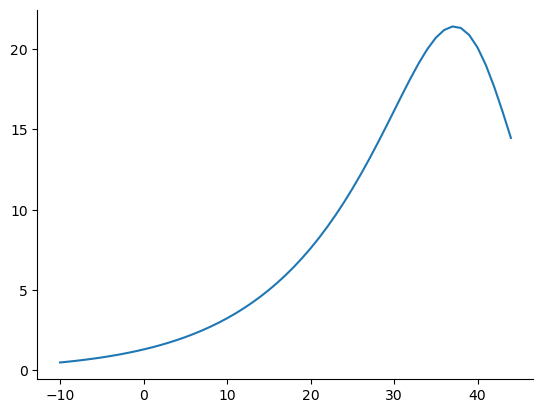

In [10]:
T_soil_list = np.arange(-10, 45, 1)
Vmax_pl_list = model_Millennial.calc__Vmax_pl(T_soil=T_soil_list, const_dict=model_Millennial.const_dict, param_dict=model_Millennial.param_dict)

plt.plot(T_soil_list, Vmax_pl_list)
sns.despine()
plt.show()

# Model run

## Spin up

In [11]:
### Spin up model

SOC_t0_obs = 4000

tolerance = 0.0001
max_iter = 100

c_input_ss, SOC_ss_mod, POC_ss_mod, MAOC_ss_mod, AGC_ss_mod, MIC_ss_mod, LMWC_ss_mod = model_Millennial.model_spin_up__cali_cinput(
    param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
    SOC_t0_obs=SOC_t0_obs,
    spin_up_steps=365*100,
    c_input_test=0.5,
    T_soil=10, SM=0.15,
    tolerance=tolerance, max_iter=max_iter,
)
print(c_input_ss, SOC_ss_mod)
print(POC_ss_mod, MAOC_ss_mod, AGC_ss_mod, MIC_ss_mod, LMWC_ss_mod)

>>> Success!
0.13621535294927836 4000.0648929050403
238.4769397619327 2762.8033459011235 976.2156739322788 19.805653896477764 2.7632794132278247


# Forward run model

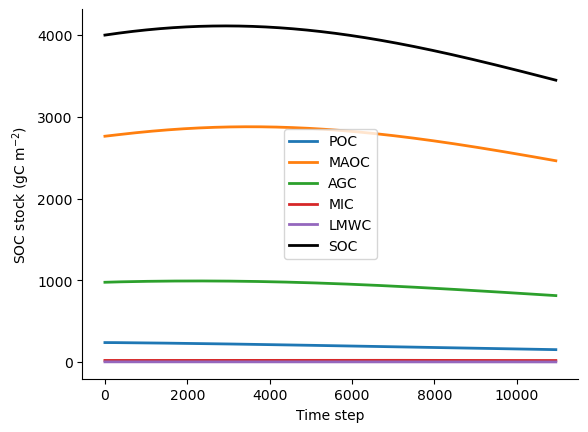

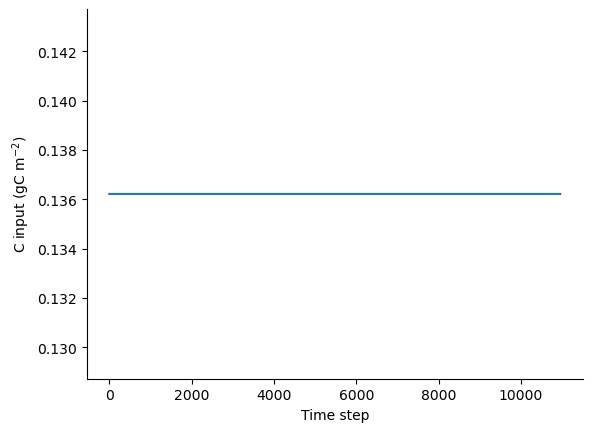

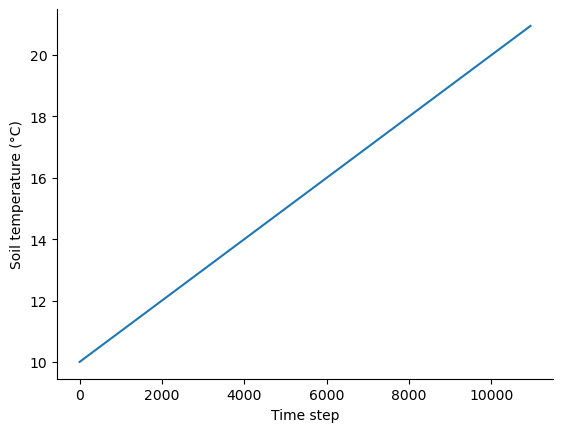

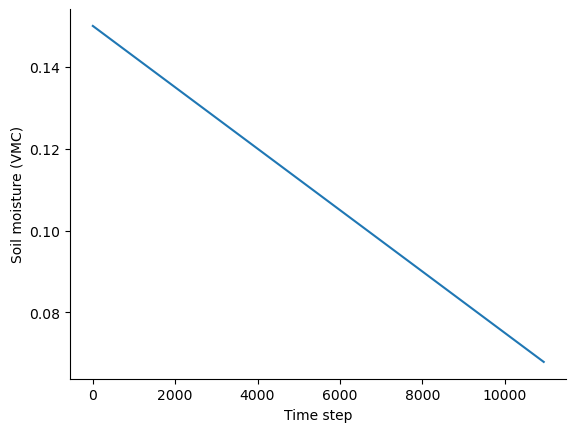

In [19]:
### Forward run model

time_list = np.arange(0, 365*30, 1)

c_input_list = [c_input_ss * 1 for i in range(len(time_list))]
# c_input_list = [c_input_ss * (1+i*0.0001) for i in range(len(time_list))]

# T_soil_list = [10 * 1 for i in range(len(time_list))]
T_soil_list = [10 * (1+i*0.0001) for i in range(len(time_list))]
# T_soil_list = [10 * (1-i*0.0001) for i in range(len(time_list))]

SM_list = [0.15 * 1 for i in range(len(time_list))]
# SM_list = [min(0.6, 0.15 * (1+i*0.0002)) for i in range(len(time_list))]
SM_list = [max(0.05, 0.15 * (1-i*0.00005)) for i in range(len(time_list))]

SOC_list, POC_list, MAOC_list, AGC_list, MIC_list, LMWC_list = model_Millennial.model_simulation(
    POC=POC_ss_mod, MAOC=MAOC_ss_mod, AGC=AGC_ss_mod, MIC=MIC_ss_mod, LMWC=LMWC_ss_mod,
    param_dict=model_Millennial.param_dict, const_dict=model_Millennial.const_dict,
    time_list=time_list,
    c_input_list=c_input_list,
    T_soil_list=T_soil_list,
    SM_list=SM_list,
    depth=0.2, pH=7.0, BD=1000, claysilt=80
)

line_width = 2.0
plt.plot(time_list, POC_list, linewidth=line_width, label='POC')
plt.plot(time_list, MAOC_list, linewidth=line_width, label='MAOC')
plt.plot(time_list, AGC_list, linewidth=line_width, label='AGC')
plt.plot(time_list, MIC_list, linewidth=line_width, label='MIC')
plt.plot(time_list, LMWC_list, linewidth=line_width, label='LMWC')
plt.plot(time_list, SOC_list, linewidth=line_width, c='black', label='SOC')
plt.legend()
plt.xlabel('Time step')
plt.ylabel('SOC stock (gC m$^{-2}$)')
sns.despine()
plt.show()

plt.plot(time_list, c_input_list, label='C input')
plt.xlabel('Time step')
plt.ylabel('C input (gC m$^{-2}$)')
sns.despine()
plt.show()

plt.plot(time_list, T_soil_list, label='Temperature')
plt.xlabel('Time step')
plt.ylabel('Soil temperature (°C)')
sns.despine()
plt.show()

plt.plot(time_list, SM_list, label='Soil moisture')
plt.xlabel('Time step')
plt.ylabel('Soil moisture (VMC)')
sns.despine()
plt.show()